In [148]:
#!/bin/bash
! curl -L -o medical-insurance-cost-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/hetmengar/medical-insurance-cost-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 16437  100 16437    0     0  18295      0 --:--:-- --:--:-- --:--:-- 18295


In [149]:
!unzip medical-insurance-cost-prediction

Archive:  medical-insurance-cost-prediction.zip
replace medical-charges.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
df = pd.read_csv('/content/medical-charges.csv')

In [152]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [153]:
df.shape

(1338, 7)

In [154]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [155]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [156]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [157]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [159]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [160]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [161]:
df.duplicated().sum()

np.int64(1)

In [162]:
df.drop_duplicates(inplace=True)

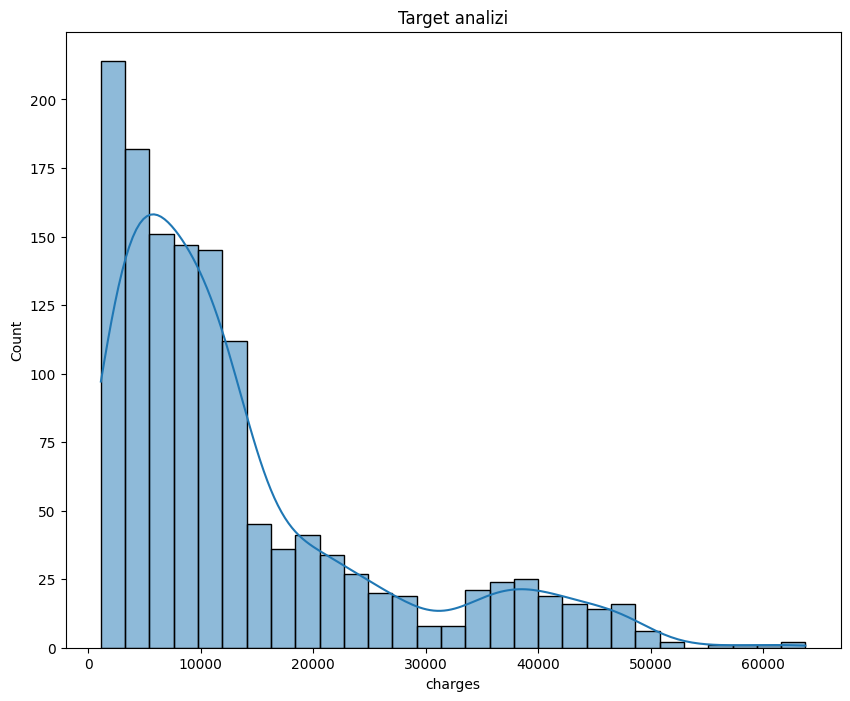

In [163]:
plt.figure(figsize=(10, 8))
sns.histplot(df['charges'], kde=True)
plt.title('Target analizi')
plt.show()

In [164]:
num_cols = df.select_dtypes(include= np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
num_cols = num_cols.drop('charges')

In [165]:
num_cols

Index(['age', 'bmi', 'children'], dtype='object')

In [166]:
cat_cols

Index(['sex', 'smoker', 'region'], dtype='object')

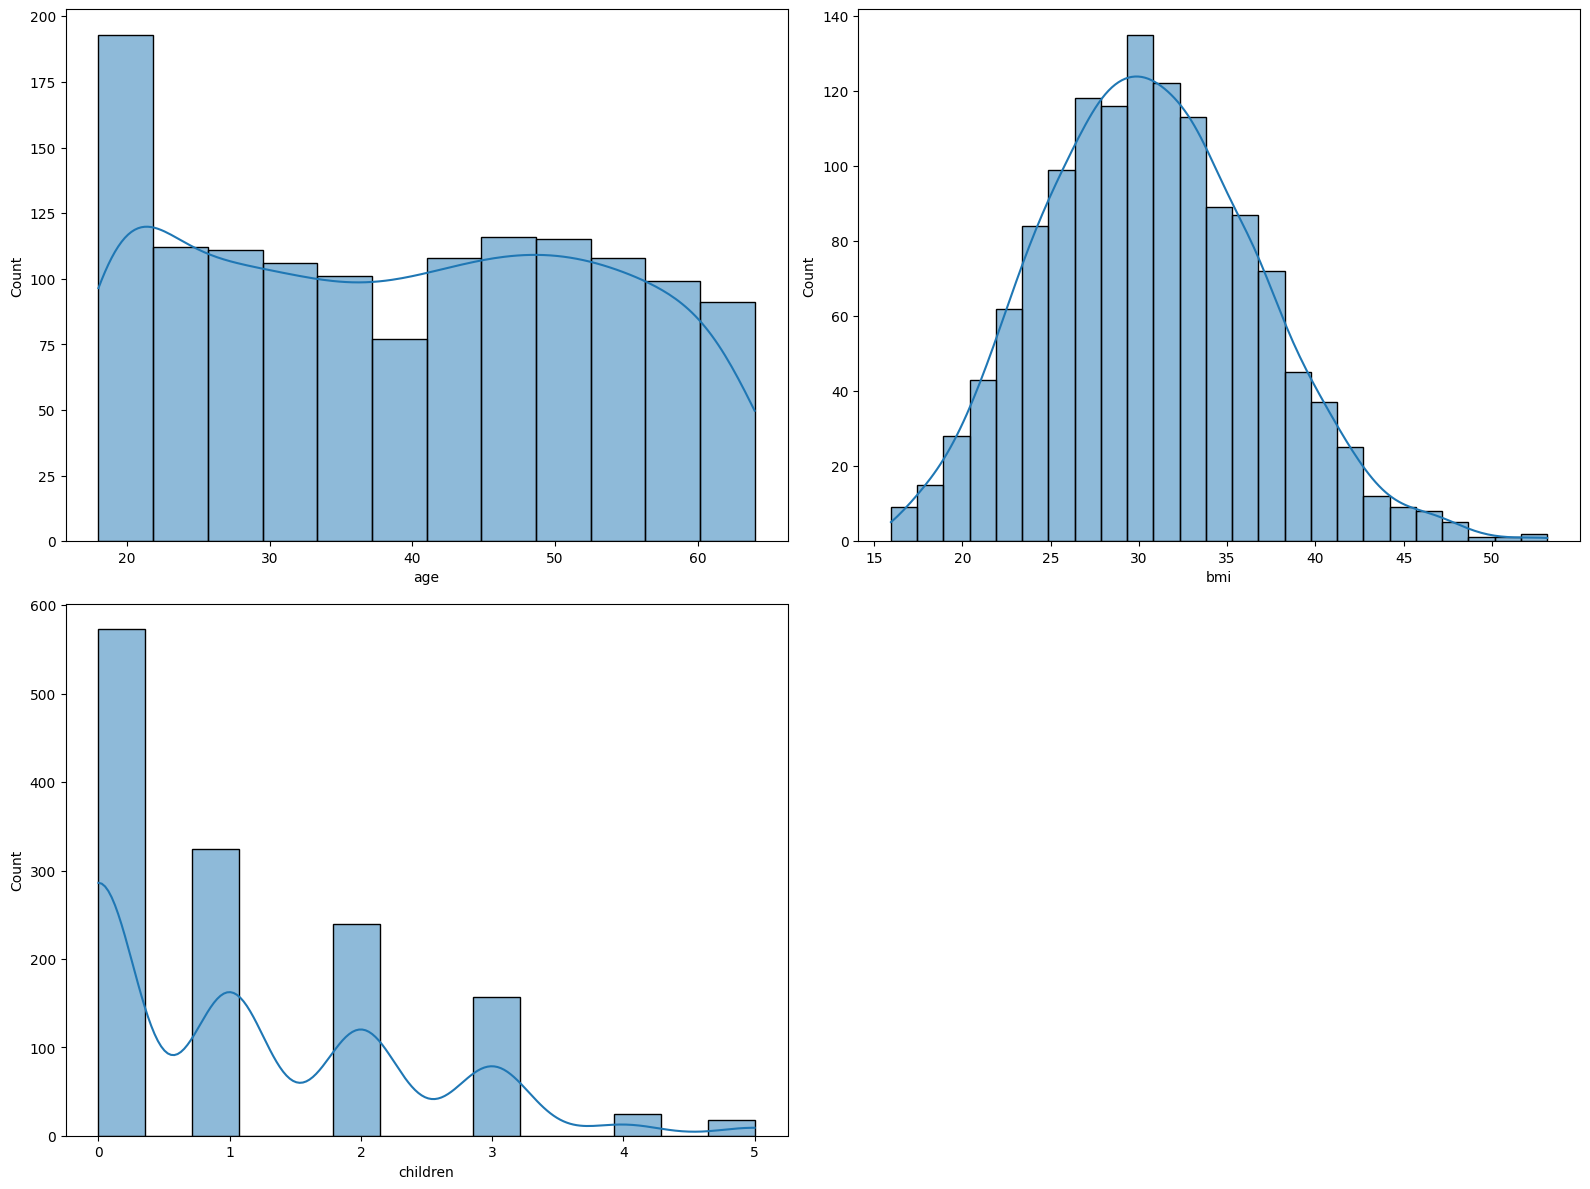

In [167]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols):
  plt.subplot(2, 2, i+1)
  sns.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()

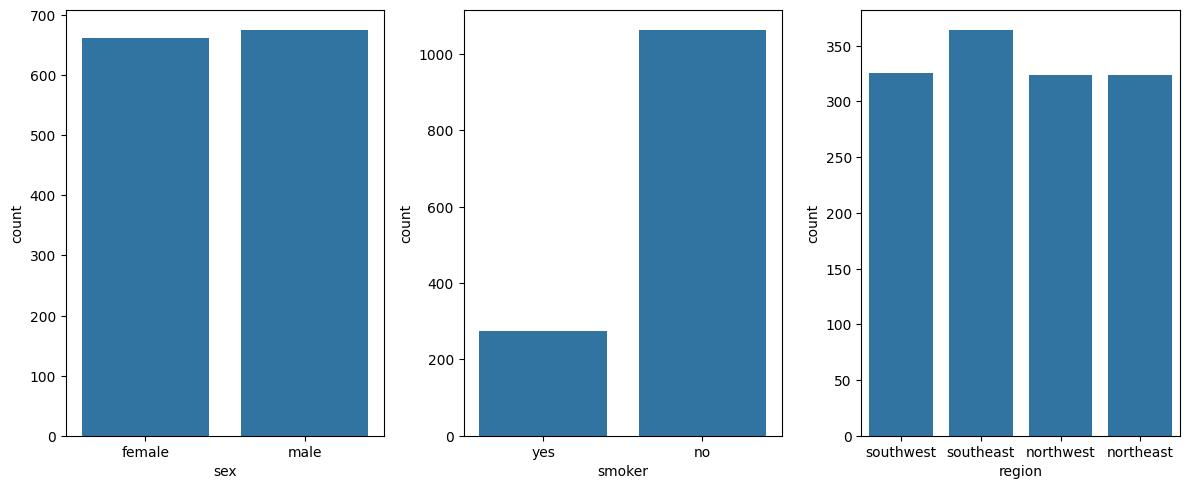

In [168]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(cat_cols):
  plt.subplot(1, 3, i+1)
  sns.countplot(data=df, x=col)

plt.tight_layout()
plt.show()

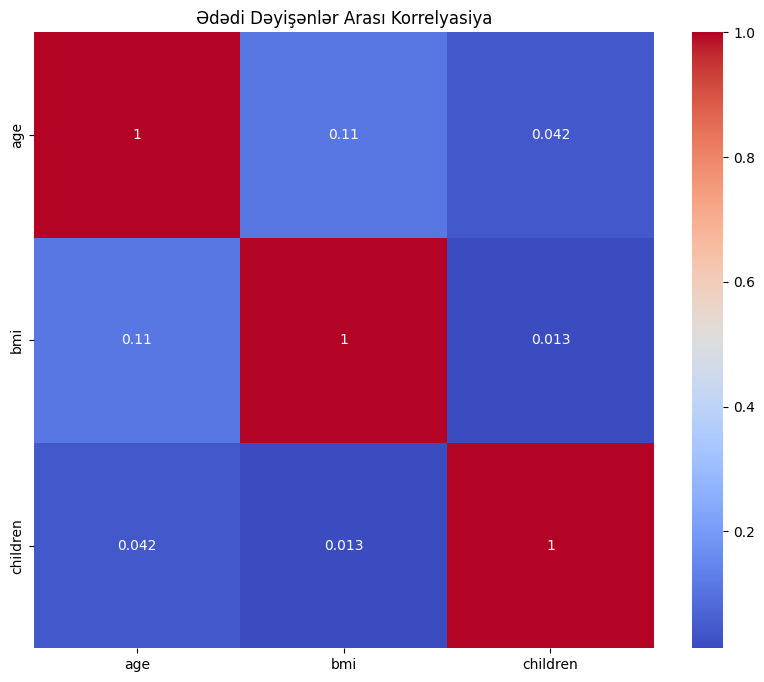

In [169]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Ədədi Dəyişənlər Arası Korrelyasiya')
plt.show()

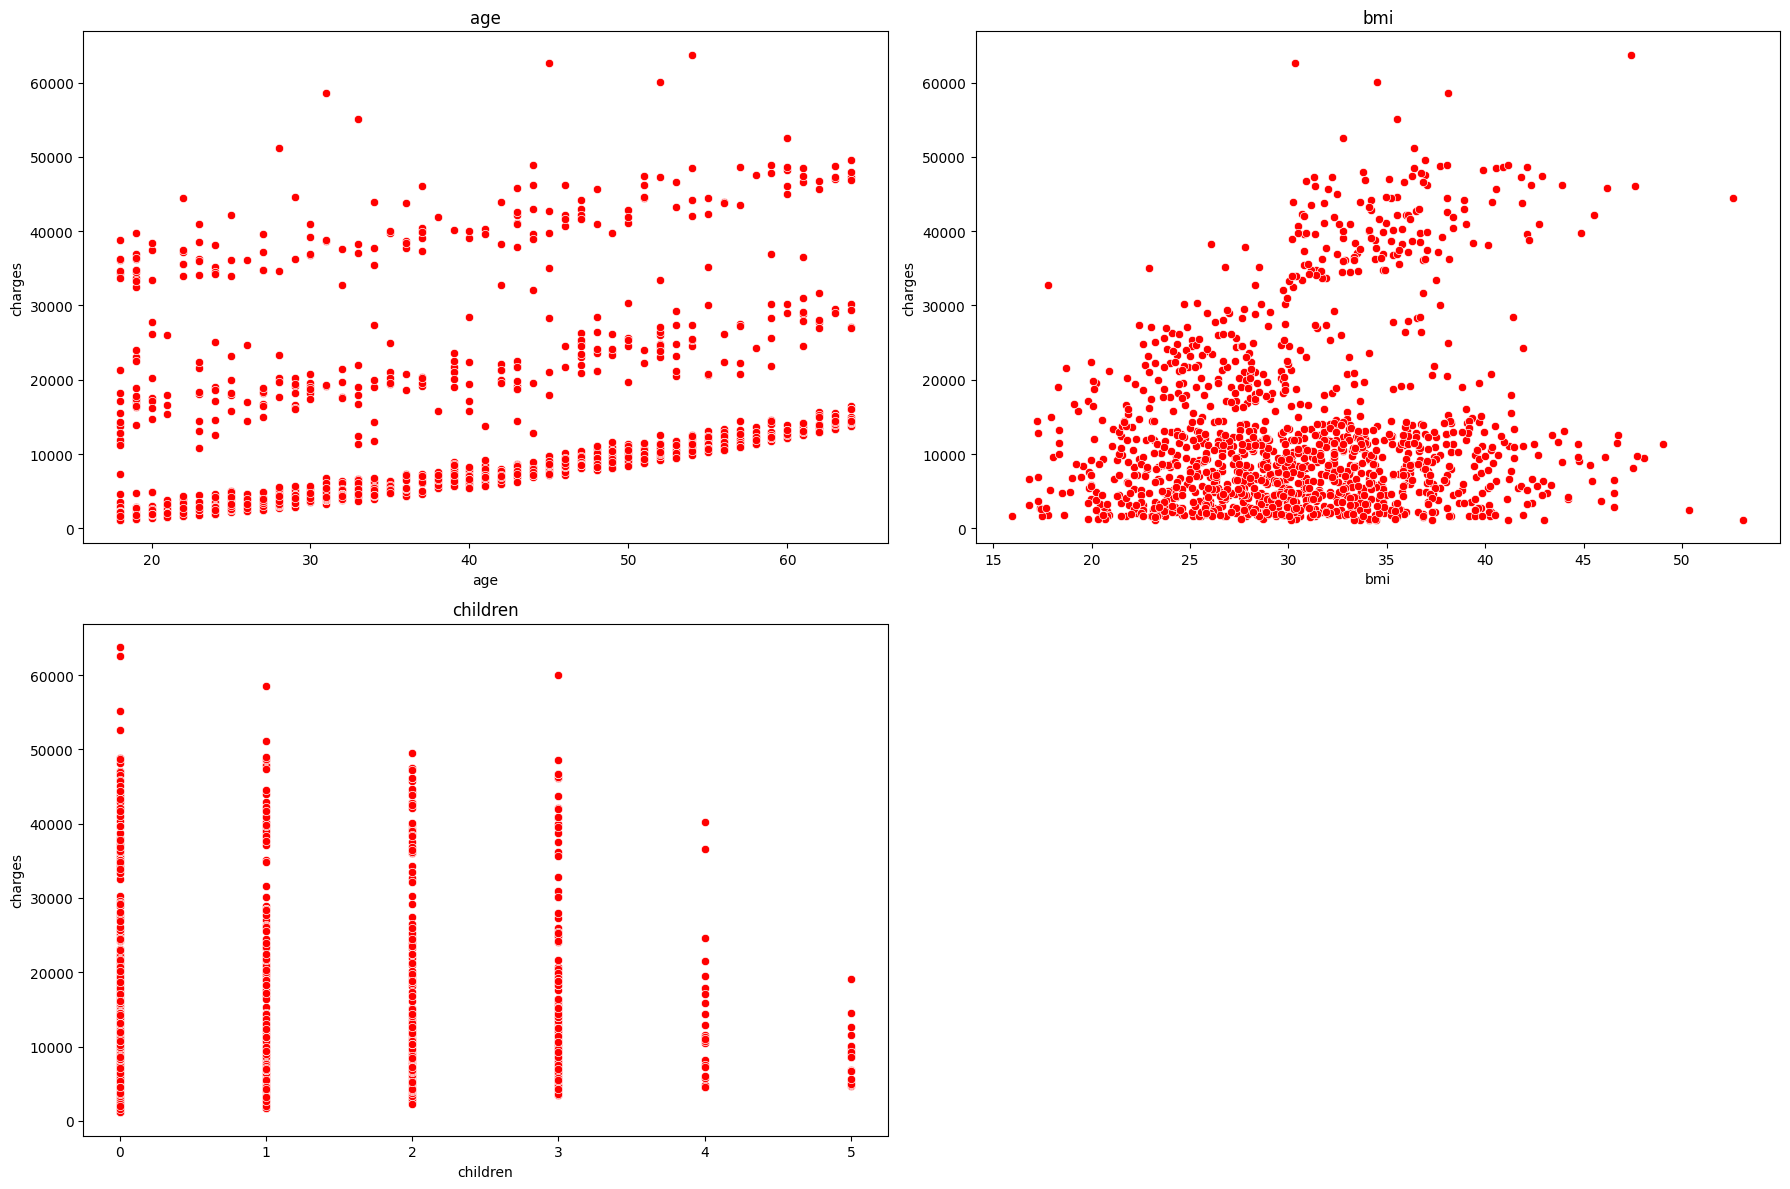

In [170]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df[col], y=df['charges'], color='red')
    plt.title(col)

plt.tight_layout()
plt.show()


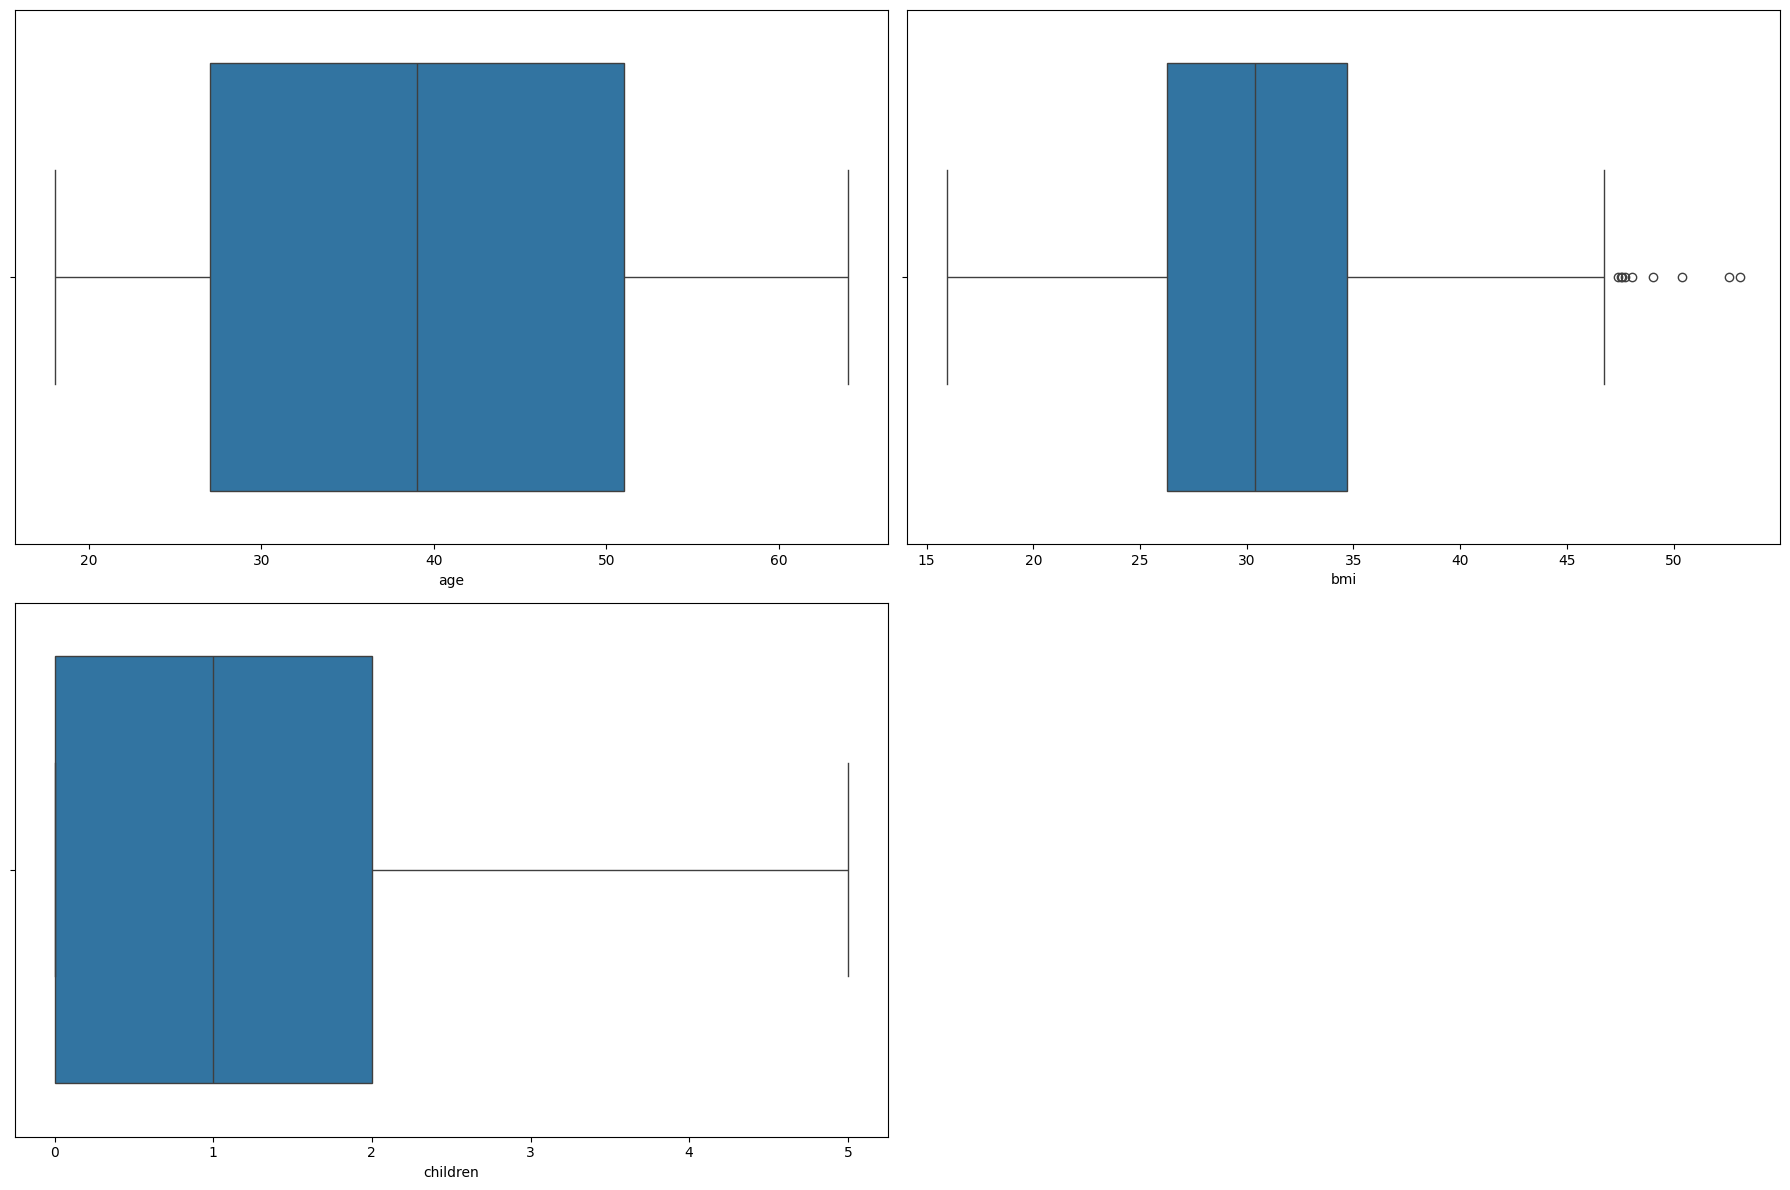

In [171]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()

In [172]:
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]

In [173]:
X = df.drop('charges', axis=1)
y = df['charges']

In [174]:
from sklearn.model_selection import  train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [175]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore'))
])

In [176]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [177]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('one-hot', OneHotEncoder(handle_unknown='ignore'))])

In [178]:
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline , num_cols)
], remainder='passthrough')

# LinearRegression

In [179]:
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('preprocess' , transformer),
    ('linear_regression' , LinearRegression())
])

In [180]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'smoker', 'region'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object'))])),
                ('linear_regression', LinearRegression())])

In [181]:
y_liner_pred = linear_pipeline.predict(X_test)

In [182]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_test, y_liner_pred)
mae = mean_absolute_error(y_test, y_liner_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_liner_pred))

print(f' R2: {r2}, \n MAE: {mae}, \n RMSE: {rmse}')

 R2: 0.7448498340547971, 
 MAE: 4125.9426765368, 
 RMSE: 5955.295898643497


.

# DecisionTreeRegressor

In [195]:
from sklearn.tree import DecisionTreeRegressor

decision_pipeline = Pipeline([
    ('preprocess', transformer),
    ('decision_tree', DecisionTreeRegressor(
                        max_depth=5,
                        min_samples_split=10,
                        min_samples_leaf=5,
                        random_state=42))
])

In [196]:
decision_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'smoker', 'region'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object'))])),
                ('decision_tree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

In [197]:
y_decision_pred = decision_pipeline.predict(X_test)

In [198]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_test, y_decision_pred)
mae = mean_absolute_error(y_test, y_decision_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_decision_pred))

print(f' R2: {r2}, \n MAE: {mae}, \n RMSE: {rmse}')

 R2: 0.8397603072978543, 
 MAE: 2691.9124709403595, 
 RMSE: 4719.440000258716


.

# RandomForestRegressor

In [212]:
from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline([
    ('preprocess', transformer),

    ('random_forest', RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [213]:
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'smoker', 'region'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object'))])),
                ('random_forest',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=5,
                                       min_samples_split=10, n_jobs=-1,
                                       random_state=42))])

In [214]:
y_rfr_pred = random_forest_pipeline.predict(X_test)

In [215]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_test, y_rfr_pred)
mae = mean_absolute_error(y_test, y_rfr_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_rfr_pred))

print(f' R2: {r2}, \n MAE: {mae}, \n RMSE: {rmse}')

 R2: 0.8517742862934777, 
 MAE: 2548.137032718073, 
 RMSE: 4539.073262604715
